# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")
sns.set_palette("Set2")

### Load Dataset

In [2]:
data = pd.read_csv("D:\monthly_spending_dataset_2020_2025.csv")

data.head()

<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\m'
C:\Users\geeky\AppData\Local\Temp\ipykernel_12508\2039186723.py:1: SyntaxWarning: invalid escape sequence '\m'
  data = pd.read_csv("D:\monthly_spending_dataset_2020_2025.csv")


,Month,Groceries,Rent,Transportation,Gym,Utilities,Healthcare,Investments,Savings,EMI/Loans,Dining & Entertainment,Shopping & Wants,Total Expenditure,Income
0,01-01-2020,4860,10000,2595,888,1520,1930,4311,4232,0,3138,1121,30363,40000
1,01-02-2020,6135,10000,2371,851,1630,1923,5939,7329,0,3185,2332,34366,40000
2,01-03-2020,6853,10000,2715,1143,1776,1185,4700,3625,0,2684,1459,32515,36000
3,01-04-2020,6904,10000,2582,869,1975,1274,4420,6426,0,2475,2806,33305,36000
4,01-05-2020,4562,10000,3028,830,1984,1631,4410,3647,0,2146,1020,29611,36000


### Basic Info

In [3]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69 entries, 0 to 68
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Month                   69 non-null     object
 1   Groceries               69 non-null     int64 
 2   Rent                    69 non-null     int64 
 3   Transportation          69 non-null     int64 
 4   Gym                     69 non-null     int64 
 5   Utilities               69 non-null     int64 
 6   Healthcare              69 non-null     int64 
 7   Investments             69 non-null     int64 
 8   Savings                 69 non-null     int64 
 9   EMI/Loans               69 non-null     int64 
 10  Dining & Entertainment  69 non-null     int64 
 11  Shopping & Wants        69 non-null     int64 
 12  Total Expenditure       69 non-null     int64 
 13  Income                  69 non-null     int64 
dtypes: int64(13), object(1)
memory usage: 7.7+ KB


,Groceries,Rent,Transportation,Gym,Utilities,Healthcare,Investments,Savings,EMI/Loans,Dining & Entertainment,Shopping & Wants,Total Expenditure,Income
count,69.000000,69.00000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000
mean,6286.913043,11000.00000,2569.260870,967.768116,1978.898551,1750.420290,6317.000000,7612.550725,1130.434783,2739.594203,1963.753623,36704.043478,50446.376812
std,1233.330400,1424.57424,577.704373,149.508523,304.688228,577.078173,1459.367671,2257.266674,2363.403848,679.530641,578.126803,5843.735745,10268.750135
min,4154.000000,10000.00000,1501.000000,700.000000,1514.000000,837.000000,3952.000000,3625.000000,0.000000,1501.000000,1020.000000,28791.000000,36000.000000
25%,5158.000000,10000.00000,2095.000000,851.000000,1683.000000,1289.000000,5161.000000,6072.000000,0.000000,2146.000000,1470.000000,32829.000000,43200.000000
50%,6368.000000,10000.00000,2604.000000,1001.000000,1980.000000,1635.000000,6255.000000,7329.000000,0.000000,2743.000000,1902.000000,34111.000000,48000.000000
75%,6931.000000,13000.00000,3035.000000,1084.000000,2240.000000,2068.000000,7089.000000,9430.000000,0.000000,3185.000000,2369.000000,40672.000000,64000.000000
max,8983.000000,13000.00000,3482.000000,1196.000000,2471.000000,2958.000000,9496.000000,12074.000000,6000.000000,3991.000000,2981.000000,49167.000000,64000.000000


### Check Missing Values

In [4]:
data.isnull().sum()

Month                     0
Groceries                 0
Rent                      0
Transportation            0
Gym                       0
Utilities                 0
Healthcare                0
Investments               0
Savings                   0
EMI/Loans                 0
Dining & Entertainment    0
Shopping & Wants          0
Total Expenditure         0
Income                    0
dtype: int64

### Convert Date

In [5]:
data['Month'] = pd.to_datetime(data['Month'])
data['Year'] = data['Month'].dt.year

### Feature Engineering

In [6]:
data['Savings_Rate'] = (data['Savings'] / data['Income']).round(3)

### Monthly Expenditure Trend

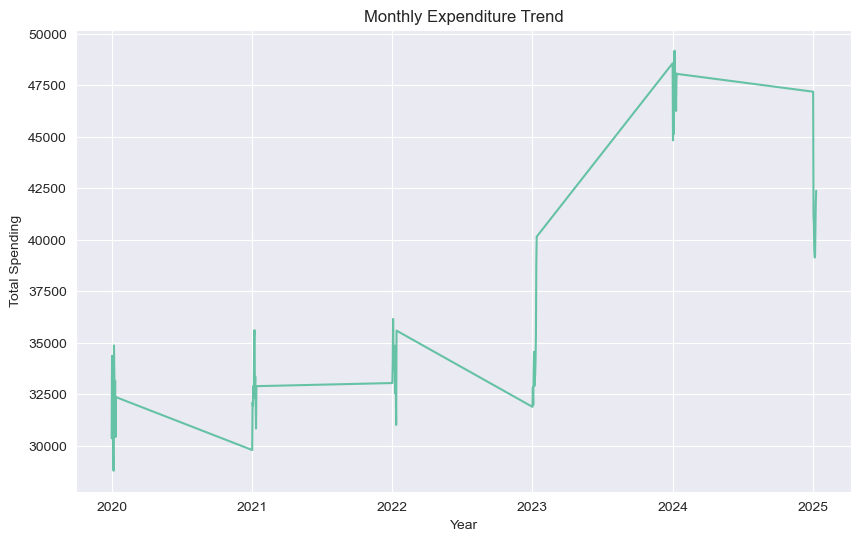

In [7]:
plt.figure(figsize=(10,6))

data = data.sort_values(by="Month")
plt.plot(data['Month'], data['Total Expenditure'])

plt.title("Monthly Expenditure Trend")
plt.xlabel("Year")
plt.ylabel("Total Spending")

plt.show()

### Income vs Expenses

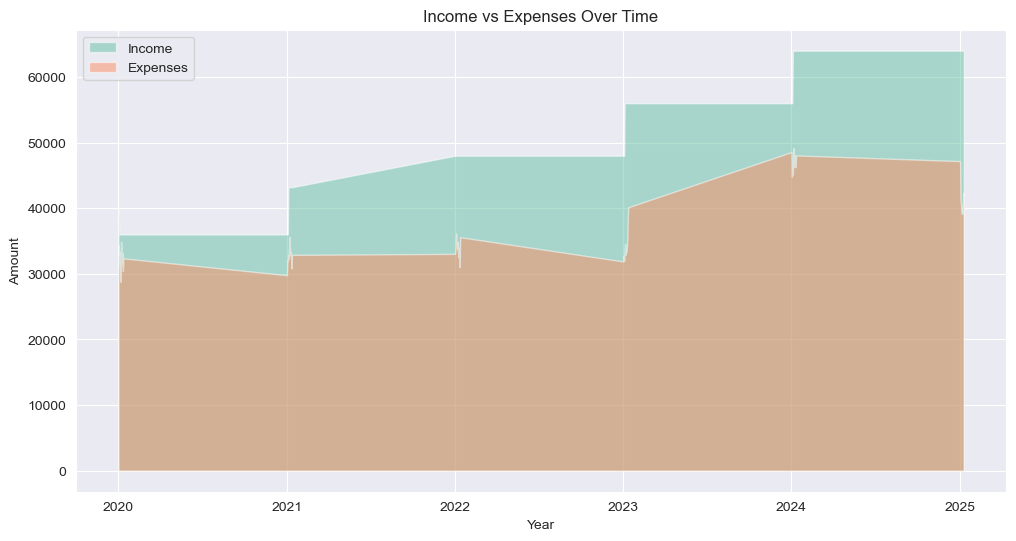

In [8]:
plt.figure(figsize=(12,6))

plt.fill_between(data['Month'], data['Income'], alpha=0.5, label="Income")
plt.fill_between(data['Month'], data['Total Expenditure'], alpha=0.5, label="Expenses")

plt.title("Income vs Expenses Over Time")
plt.xlabel("Year")
plt.ylabel("Amount")

plt.legend()
plt.show()

#### Expenses are increasing over time

### Savings Rate

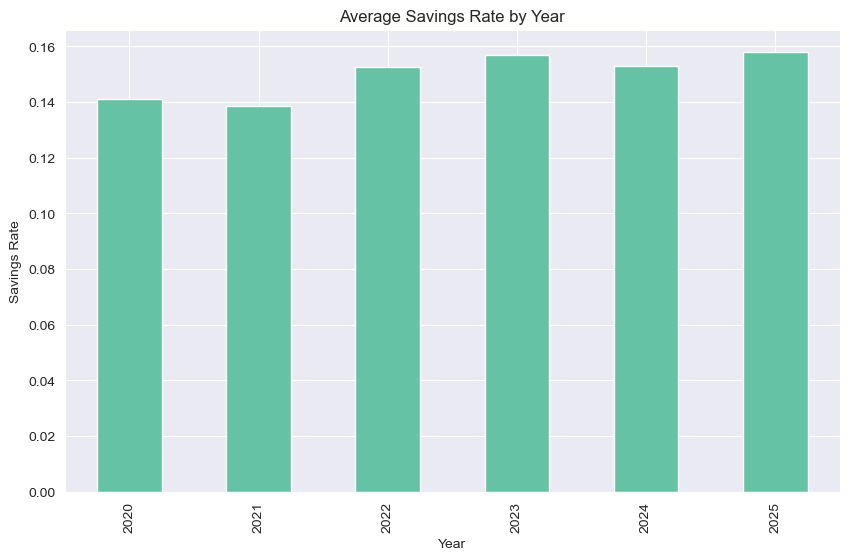

In [9]:
yearly_savings = data.groupby('Year')['Savings_Rate'].mean()

plt.figure(figsize=(10,6))
yearly_savings.plot(kind='bar')

plt.title("Average Savings Rate by Year")
plt.ylabel("Savings Rate")
plt.xlabel("Year")

plt.show()

#### Savings rate shows gradual improvement

### Correlation Heatmap

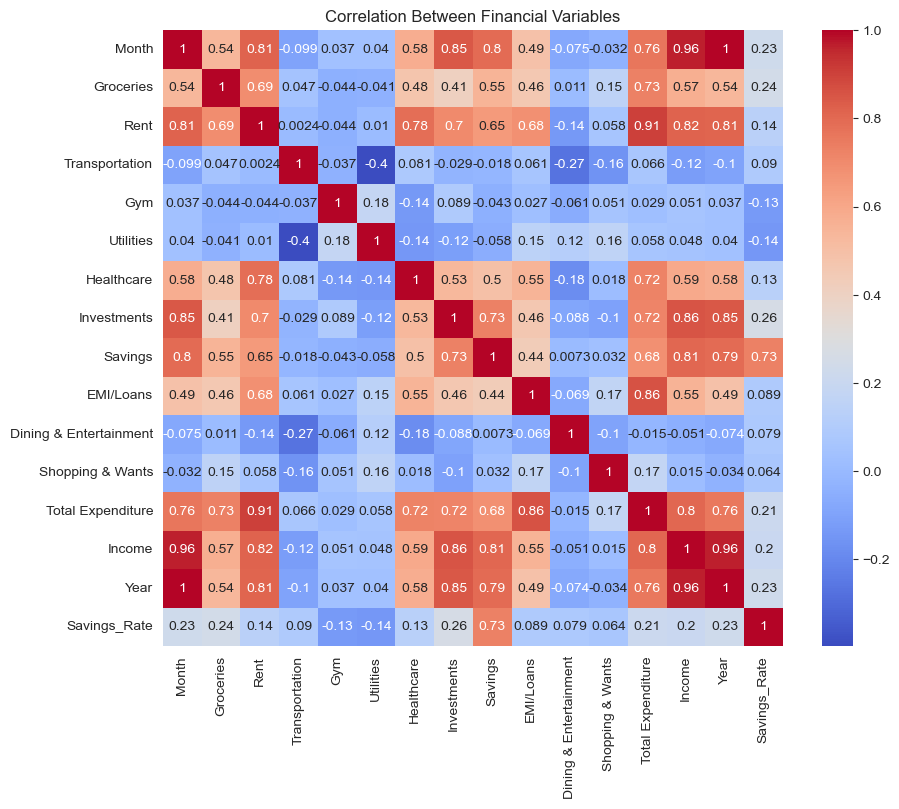

In [10]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(data.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Between Financial Variables")

plt.show()

### Expense Category Distribution

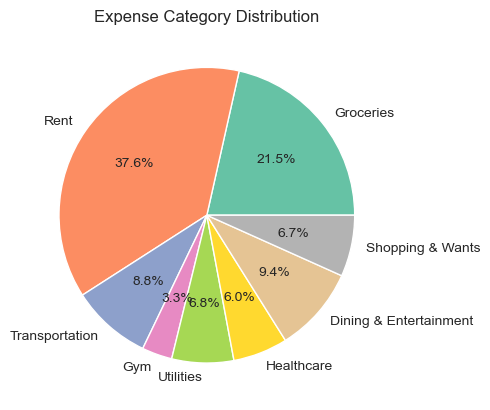

In [11]:
expense_columns = [
    'Groceries','Rent','Transportation','Gym','Utilities',
    'Healthcare','Dining & Entertainment','Shopping & Wants'
]

data[expense_columns].sum().plot(kind='pie', autopct='%1.1f%%')

plt.title("Expense Category Distribution")
plt.show()

# Preparing Data for AI Model

### Feature Selection

In [12]:
features = data[['Income','Groceries','Rent','Transportation','Utilities','Healthcare']]
target = data['Total Expenditure']

### Train-Test Split

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

### Train Model

In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

#### Predictions

In [15]:
predictions = model.predict(X_test)

#### Model Accuracy

from sklearn.metrics import r2_score

r2_score(y_test, predictions)

### Model Prediction Performance Analysis

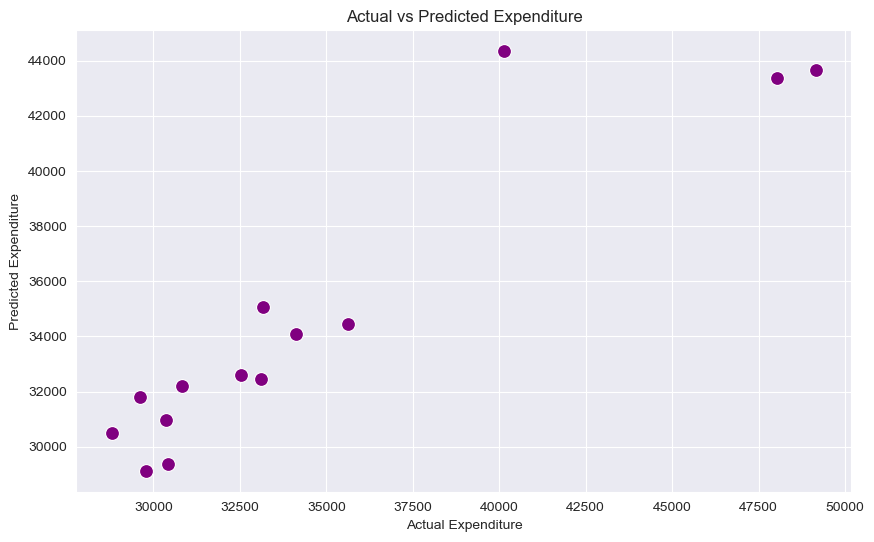

In [16]:
plt.figure(figsize=(10,6))

sns.scatterplot(x=y_test, y=predictions, color="purple", s=100)

plt.xlabel("Actual Expenditure")
plt.ylabel("Predicted Expenditure")
plt.title("Actual vs Predicted Expenditure")

plt.show()

### Residual Plot

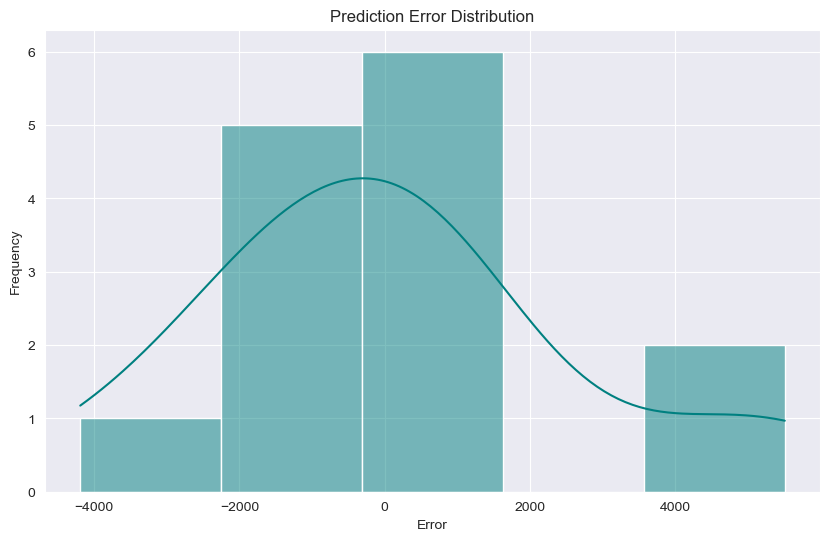

In [17]:
residuals = y_test - predictions

plt.figure(figsize=(10,6))
sns.histplot(residuals, kde=True, color="teal")

plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")

plt.show()

### Feature Importance

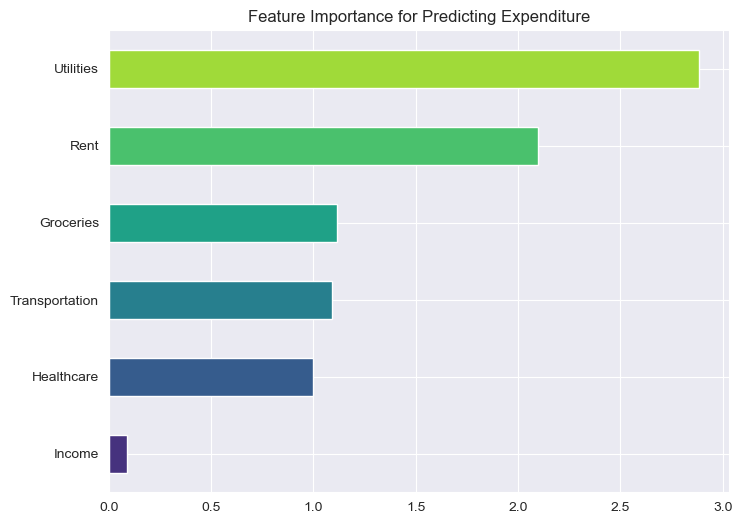

In [18]:
importance = pd.Series(model.coef_, index=features.columns)

plt.figure(figsize=(8,6))

importance.sort_values().plot(
    kind='barh',
    color=sns.color_palette("viridis", len(importance))
)

plt.title("Feature Importance for Predicting Expenditure")

plt.show()

#### Utilities and Rent are major cost drivers

### Line Chart (Actual vs Predicted)

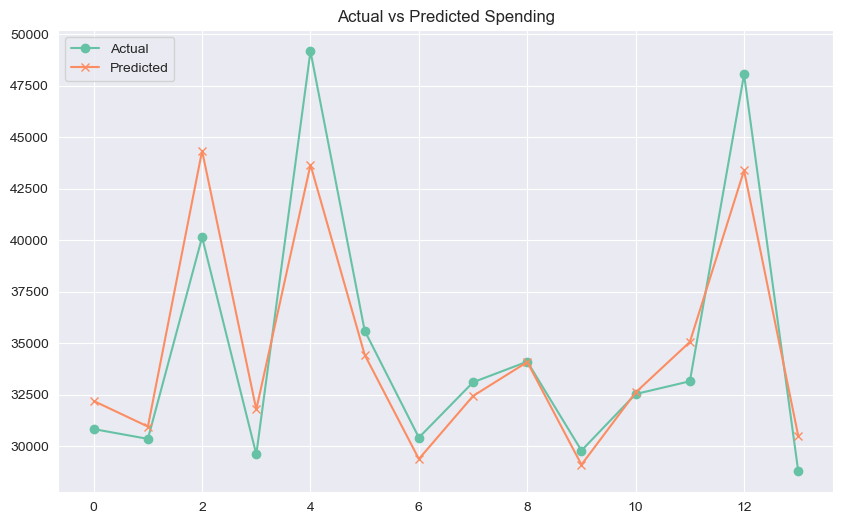

In [19]:
plt.figure(figsize=(10,6))

plt.plot(y_test.values, label="Actual", marker='o')
plt.plot(predictions, label="Predicted", marker='x')

plt.legend()
plt.title("Actual vs Predicted Spending")

plt.show()

### Future Prediction

In [20]:
sample_input = pd.DataFrame(
    [[50000,7000,13000,2500,2200,1500]],
    columns=features.columns
)

prediction = model.predict(sample_input)

predicted_value = prediction[0]

print(f"Predicted Monthly Expenditure: ₹{predicted_value:,.2f}")

Predicted Monthly Expenditure: ₹41,936.61


#### Model predicts expenditure with good accuracy